# HFE Cooldown Models

This notebook keeps two reduced-order descriptions of the cooldown problem.

1. **Cycle-averaged screening model**: one circulation turnover is treated as one cycle with a fixed temperature drop.
2. **Transient energy-balance model**: the HFE inventory and stainless hardware are treated as a lumped thermal mass and integrated in time.

Confirmed hardware values used here:

- HFE inventory in tank: `3 L`
- HFE inventory in piping: `1 L`
- Heat exchanger: `6 m` of `1/4 in OD`, `0.05 in wall` stainless tubing, about `0.12 m^2` external area

The transient model also carries a small uncertainty envelope. The main uncertain inputs are the effective HFE-side resistance around the coil and the LN2-side boiling / gas heat-transfer coefficients.


In [1]:
from __future__ import annotations

from dataclasses import replace
from itertools import product
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

nb_path = Path.cwd()
repo_root = nb_path
for candidate in [nb_path, *nb_path.parents]:
    if (candidate / "analysis").exists() and (candidate / "data").exists():
        repo_root = candidate
        break

src_dir = repo_root / "analysis" / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

import orca


## 1. Cycle-Averaged Screening Model

This is a quick scoping model kept only in this notebook. It is useful for order-of-magnitude planning, but it is **not** an energy-balance model.

Equations used:

$$
\tau_{\mathrm{turn}} = \frac{V_{\mathrm{HFE}}}{Q_{\mathrm{HFE}}}
$$

$$
T_{n+1} = T_n - \Delta T_{\mathrm{cycle}}
$$

$$
\dot m_{\mathrm{LN2},n} = \dot m_{\mathrm{LN2,ref}}
\frac{T_n - T_{\mathrm{LN2}}}{T_0 - T_{\mathrm{LN2}}}
$$

$$
m_{\mathrm{LN2}}(t_n) = \sum_{i=1}^{n} \dot m_{\mathrm{LN2},i}\,\tau_{\mathrm{turn}}
$$

In words: one loop turnover is one model cycle, the bulk temperature drops by a fixed amount every cycle, and LN2 feed is scaled down as the system gets colder.


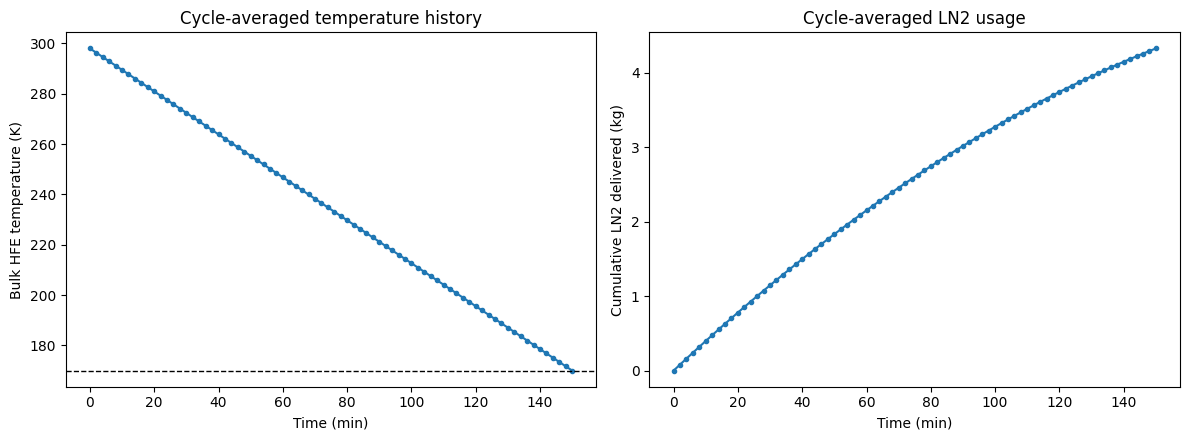

,quantity,value
0,Turnover time (min),2.000
1,Cycles simulated,75.000
2,Final temperature (K),170.000
3,LN2 delivered at final point (kg),4.328


In [2]:
def simulate_cycle_averaged_screening_model(
    system_model: orca.SystemModel,
    *,
    start_temp_k: float | None = None,
    stop_temp_k: float | None = None,
    hfe_flow_lpm: float = 2.0,
    ln2_reference_flow_lpm: float = 0.05,
    cycle_count: int = 75,
) -> pd.DataFrame:
    """Notebook-only screening model based on a fixed drop per loop turnover."""

    start = system_model.initial_temp_k if start_temp_k is None else float(start_temp_k)
    stop = system_model.target_temp_k if stop_temp_k is None else float(stop_temp_k)
    turnover_time_s = system_model.loop_turnover_time_s(hfe_flow_lpm)
    fixed_drop_k = (start - stop) / max(cycle_count, 1)

    rows = [
        {
            "cycle": 0,
            "time_s": 0.0,
            "temp_k": start,
            "ln2_flow_lpm": ln2_reference_flow_lpm,
            "ln2_used_kg": 0.0,
            "ln2_cumulative_kg": 0.0,
        }
    ]

    temp_k = start
    cumulative_ln2_kg = 0.0

    for cycle in range(1, cycle_count + 1):
        if temp_k <= stop:
            break

        flow_fraction = max(
            0.0,
            (temp_k - system_model.ln2_saturation_temp_k)
            / max(start - system_model.ln2_saturation_temp_k, 1e-12),
        )
        ln2_flow_lpm = ln2_reference_flow_lpm * flow_fraction
        ln2_mass_flow_kg_s = orca.lpm_to_m3_s(ln2_flow_lpm) * system_model.ln2_density_kg_m3
        ln2_used_kg = ln2_mass_flow_kg_s * turnover_time_s
        cumulative_ln2_kg += ln2_used_kg
        temp_k = max(stop, temp_k - fixed_drop_k)

        rows.append(
            {
                "cycle": cycle,
                "time_s": cycle * turnover_time_s,
                "temp_k": temp_k,
                "ln2_flow_lpm": ln2_flow_lpm,
                "ln2_used_kg": ln2_used_kg,
                "ln2_cumulative_kg": cumulative_ln2_kg,
            }
        )

    return pd.DataFrame(rows)


model = orca.default_system_model()
nominal_scenario = next(s for s in orca.default_scenarios() if s.name == "Nominal")

screening_result = simulate_cycle_averaged_screening_model(
    model,
    start_temp_k=model.initial_temp_k,
    stop_temp_k=model.target_temp_k,
    hfe_flow_lpm=nominal_scenario.hfe_flow_lpm,
    ln2_reference_flow_lpm=nominal_scenario.ln2_flow_lpm,
    cycle_count=75,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(screening_result["time_s"] / 60.0, screening_result["temp_k"], marker="o", ms=3)
axes[0].axhline(model.target_temp_k, color="k", ls="--", lw=1.0)
axes[0].set_xlabel("Time (min)")
axes[0].set_ylabel("Bulk HFE temperature (K)")
axes[0].set_title("Cycle-averaged temperature history")

axes[1].plot(screening_result["time_s"] / 60.0, screening_result["ln2_cumulative_kg"], marker="o", ms=3)
axes[1].set_xlabel("Time (min)")
axes[1].set_ylabel("Cumulative LN2 delivered (kg)")
axes[1].set_title("Cycle-averaged LN2 usage")

plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "quantity": [
            "Turnover time (min)",
            "Cycles simulated",
            "Final temperature (K)",
            "LN2 delivered at final point (kg)",
        ],
        "value": [
            model.loop_turnover_time_s(nominal_scenario.hfe_flow_lpm) / 60.0,
            int(screening_result["cycle"].iloc[-1]),
            screening_result["temp_k"].iloc[-1],
            screening_result["ln2_cumulative_kg"].iloc[-1],
        ],
    }
).round(3)


## 2. Transient Energy-Balance Model

This is the reusable ORCA model in `analysis/src/orca/cooldown.py`. It enforces a lumped energy balance on the full HFE inventory plus the stainless hardware.

Equations used:

$$
C(T)\frac{dT}{dt} = Q_{\mathrm{ambient}}(T) - Q_{\mathrm{HX}}(T)
$$

$$
C(T) = m_{\mathrm{HFE}}(T)c_{p,\mathrm{HFE}}(T) + m_{\mathrm{steel}}c_{p,\mathrm{steel}}
$$

$$
Q_{\mathrm{ambient}} = UA_{\mathrm{ambient}}\,(T_{\mathrm{ambient}} - T)
$$

$$
Q_{\mathrm{HX}} = \text{heat removed through the coil, limited by both coil } UA \text{ and LN2 latent / sensible capacity}
$$

The uncertainty band below is an envelope, not a statistical fit. It varies these inputs around the nominal insulated operating case:

- effective stagnant HFE layer around the coil: `1 mm` to `4 mm`
- LN2 boiling-side heat-transfer coefficient: `500` to `1500 W m^-2 K^-1`
- LN2 gas-side heat-transfer coefficient after dryout: `5` to `15 W m^-2 K^-1`


In [3]:
def build_transient_uncertainty_ensemble(
    base_model: orca.SystemModel,
    base_scenario: orca.CooldownScenario,
    *,
    film_thickness_mm: tuple[float, ...] = (1.0, 2.0, 4.0),
    h_boil_values_w_m2k: tuple[float, ...] = (500.0, 1000.0, 1500.0),
    h_gas_values_w_m2k: tuple[float, ...] = (5.0, 10.0, 15.0),
    dt_s: float = 1.0,
    max_time_h: float = 6.0,
) -> dict[str, object]:
    results = []
    for film_mm, h_boil, h_gas in product(
        film_thickness_mm,
        h_boil_values_w_m2k,
        h_gas_values_w_m2k,
    ):
        varied_model = replace(
            base_model,
            stagnant_hfe_film_thickness_m=film_mm / 1e3,
        )
        varied_scenario = replace(
            base_scenario,
            h_boil_w_m2k=h_boil,
            h_gas_w_m2k=h_gas,
        )
        results.append(
            orca.simulate_cooldown(
                varied_scenario,
                model=varied_model,
                dt_s=dt_s,
                max_time_h=max_time_h,
                stop_on_target=False,
            )
        )

    time_s = results[0].time_s
    temp_stack = np.vstack([result.bulk_temp_k for result in results])
    removed_stack = np.vstack([result.removed_heat_w for result in results])

    return {
        "results": results,
        "time_s": time_s,
        "temp_low_k": temp_stack.min(axis=0),
        "temp_high_k": temp_stack.max(axis=0),
        "removed_low_w": removed_stack.min(axis=0),
        "removed_high_w": removed_stack.max(axis=0),
    }


def interpolate_value_at_time(result: orca.CooldownResult, values: np.ndarray, time_s: float) -> float:
    return float(np.interp(time_s, result.time_s, values))


transient_nominal = orca.simulate_cooldown(
    nominal_scenario,
    model=model,
    dt_s=1.0,
    max_time_h=6.0,
    stop_on_target=False,
)
uncertainty = build_transient_uncertainty_ensemble(model, nominal_scenario)

uncertainty_results = uncertainty["results"]
target_times_min = np.array([result.time_to_target_min for result in uncertainty_results], dtype=float)
finite_target_mask = np.isfinite(target_times_min)
target_ln2_kg = np.array(
    [
        interpolate_value_at_time(result, result.delivered_ln2_kg, result.time_to_target_min * 60.0)
        if np.isfinite(result.time_to_target_min)
        else np.nan
        for result in uncertainty_results
    ],
    dtype=float,
)
nominal_ln2_at_target_kg = interpolate_value_at_time(
    transient_nominal,
    transient_nominal.delivered_ln2_kg,
    transient_nominal.time_to_target_min * 60.0,
)

transient_summary = pd.DataFrame(
    {
        "quantity": [
            "Time to 170 K (min)",
            "LN2 delivered to 170 K (kg)",
            "Theoretical minimum LN2 (kg)",
            "HX external area (m^2)",
            "Total HFE inventory (L)",
        ],
        "nominal": [
            transient_nominal.time_to_target_min,
            nominal_ln2_at_target_kg,
            transient_nominal.theoretical_min_ln2_kg,
            model.heat_exchanger.external_area_m2,
            model.fluid_volume_m3 * 1e3,
        ],
        "low": [
            np.nanmin(target_times_min),
            np.nanmin(target_ln2_kg),
            transient_nominal.theoretical_min_ln2_kg,
            model.heat_exchanger.external_area_m2,
            model.fluid_volume_m3 * 1e3,
        ],
        "high": [
            np.nanmax(target_times_min),
            np.nanmax(target_ln2_kg),
            transient_nominal.theoretical_min_ln2_kg,
            model.heat_exchanger.external_area_m2,
            model.fluid_volume_m3 * 1e3,
        ],
    }
).round(3)

transient_summary


,quantity,nominal,low,high
0,Time to 170 K (min),220.003,158.892,354.560
1,LN2 delivered to 170 K (kg),8.888,6.419,14.324
2,Theoretical minimum LN2 (kg),7.327,7.327,7.327
3,HX external area (m^2),0.120,0.120,0.120
4,Total HFE inventory (L),4.000,4.000,4.000


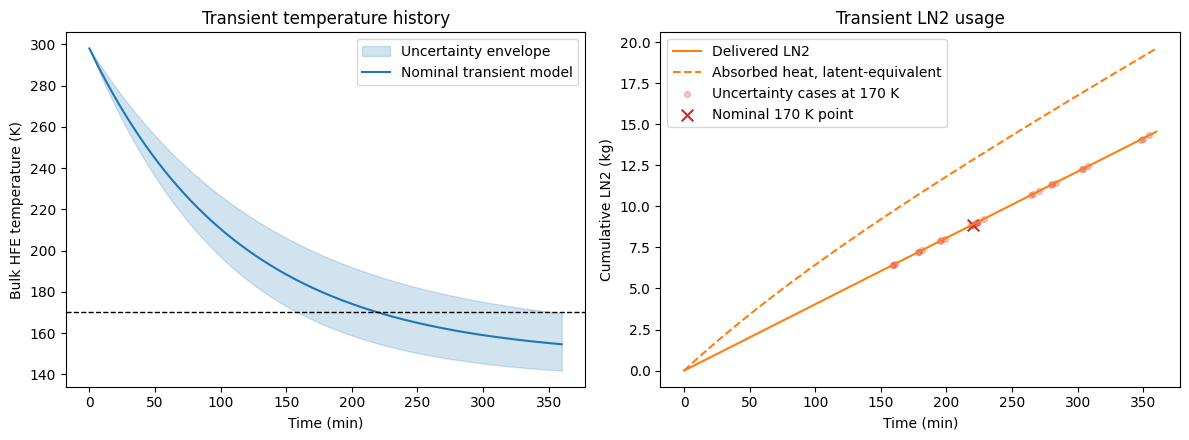

In [4]:
time_min = transient_nominal.time_s / 60.0
latent_equivalent_ln2_kg = transient_nominal.absorbed_energy_j / transient_nominal.ln2_latent_heat_j_kg

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].fill_between(
    time_min,
    uncertainty["temp_low_k"],
    uncertainty["temp_high_k"],
    color="C0",
    alpha=0.2,
    label="Uncertainty envelope",
)
axes[0].plot(time_min, transient_nominal.bulk_temp_k, color="C0", label="Nominal transient model")
axes[0].axhline(model.target_temp_k, color="k", ls="--", lw=1.0)
axes[0].set_xlabel("Time (min)")
axes[0].set_ylabel("Bulk HFE temperature (K)")
axes[0].set_title("Transient temperature history")
axes[0].legend()

axes[1].plot(time_min, transient_nominal.delivered_ln2_kg, color="C1", label="Delivered LN2")
axes[1].plot(
    time_min,
    latent_equivalent_ln2_kg,
    color="C1",
    ls="--",
    label="Absorbed heat, latent-equivalent",
)
if finite_target_mask.any():
    axes[1].scatter(
        target_times_min[finite_target_mask],
        target_ln2_kg[finite_target_mask],
        color="C3",
        alpha=0.25,
        s=18,
        label="Uncertainty cases at 170 K",
    )
axes[1].scatter(
    [transient_nominal.time_to_target_min],
    [nominal_ln2_at_target_kg],
    color="C3",
    marker="x",
    s=70,
    label="Nominal 170 K point",
)
axes[1].set_xlabel("Time (min)")
axes[1].set_ylabel("Cumulative LN2 (kg)")
axes[1].set_title("Transient LN2 usage")
axes[1].legend()

plt.tight_layout()
plt.show()


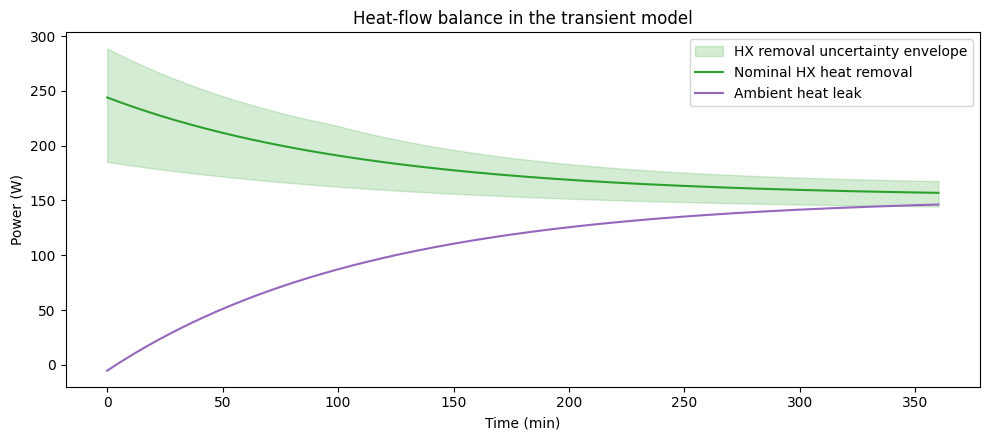

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.fill_between(
    time_min,
    uncertainty["removed_low_w"],
    uncertainty["removed_high_w"],
    color="C2",
    alpha=0.2,
    label="HX removal uncertainty envelope",
)
ax.plot(time_min, transient_nominal.removed_heat_w, color="C2", label="Nominal HX heat removal")
ax.plot(time_min, transient_nominal.ambient_heat_w, color="C4", label="Ambient heat leak")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Power (W)")
ax.set_title("Heat-flow balance in the transient model")
ax.legend()

plt.tight_layout()
plt.show()
